# PMI-отчёт: приёмка миграции хранилища `airline-dwh`

### Post-Migration Integration · Контроль качества данных после переработки слоя DDS

| Параметр | Значение |
|---|---|
| **Проект** | `airline-dwh` |
| **Объём проверки** | слой DDS после перехода на суррогатные хеш-ключи и пересборки модели |
| **Платформа** | PostgreSQL · PL/pgSQL · Python |
| **Дата прогона** | по колонке `checked_at` последнего прогона (см. таблицу ниже) |

---

## Цель проверки

Слой **DDS** был переработан: суррогатные ключи переведены с автоинкремента на детерминированные **хеш-ключи `uuid`**, измерения и факты пересобраны. Задача приёмки в том, чтобы подтвердить, что эти изменения не повредили данные.

Проверяются **четыре свойства миграции**:

- **полнота** (ничего не потеряно);
- **отсутствие дублей** по натуральному ключу;
- **целостность истории** SCD2;
- **сходимость денежных сумм**.

Все проверки реализованы процедурами слоя `dq` и складывают результат в таблицу `dq.pmi_results`. Каждый запуск получает собственный `run_id`, поэтому история прогонов сохраняется.

## Объекты проверки

Под проверку взяты **три таблицы**, подобранные так, чтобы покрыть все типы загрузки в хранилище.

| Таблица | Тип | Что репрезентирует |
|---|---|---|
| `dim_airplanes` | измерение **SCD2** | историчность версий |
| `dim_seats` | измерение **SCD1** | актуальное состояние, составной натуральный ключ |
| `fact_bookings` | **факт** | объём строк и денежная мера `total_amount` |

Сверка проходит по всей цепочке слоёв хранилища:

```
source → RAW → STAGE → ODS → DDS
```

> **STAGE из сверки исключён намеренно.** Это транзитный слой: он грузится в режиме `truncate + insert` по одному батчу и не хранит полный набор данных, поэтому сверять его состояние не с чем. Качество данных на STAGE контролируется в момент загрузки через флаг `is_valid`. В PMI стык RAW и ODS проверяется напрямую.

## Типы проверок

| Код | Тип (`check_type`) | Что выявляет |
|---|---|---|
| **RC** | `row_count` | потерю или задвоение строк на стыке слоёв |
| **SCD2** | `scd2` | нарушение историчности: лишние активные версии, пересечения и разрывы периодов |
| **DUP** | `duplicate` | дубли по натуральному ключу |
| **AGG** | `aggregate` | расхождение контрольной суммы по деньгам |

## Как устроена проверка row_count

**Принцип:** на каждом стыке слоёв число уникальных бизнес-ключей должно совпадать слева и справа.

Сложность возникает на слое **RAW**. Там данные лежат журналом событий (`I`, `U`, `D`), и один ключ встречается много раз. Чтобы сравнение было честным, сначала восстанавливаем **актуальное состояние**, то есть последнее событие по каждому ключу:

```sql
select distinct on (key)
    key, operation_type
from raw.<table>
order by key, batch_id desc, load_date desc
```

После этого отбрасываем удалённые записи (`operation_type <> 'D'`) и считаем `count(distinct key)`.

Что именно сравнивается на разных стыках:

| Стык | Слева (`src_value`) | Справа (`dwh_value`) |
|---|---|---|
| `source → raw` | уникальные ключи в источнике (FDW) | актуальное состояние RAW |
| `raw → ods` | актуальное состояние RAW | `ods`, где `is_deleted = false` |
| `ods → dds` · SCD2 | активные строки `ods` | `dds`, где `is_current = true` |
| `ods → dds` · SCD1, факт | активные строки `ods` | активные строки `dds` без стаба `-1` |

Проверка проходит, когда `src_value` равно `dwh_value` (`diff = 0`).

## Проверки историчности SCD2

В измерении SCD2 история версий хранится через `valid_from`, `valid_to` и `is_current`. Есть **три правила**, которые база сама по себе не гарантирует, поэтому их проверяем отдельно.

**SCD2-01. Одна активная версия на ключ.**

```sql
select airplane_code
from dds.dim_airplanes
where is_current = true
group by airplane_code
having count(*) > 1
```

**SCD2-02. Периоды действия версий не пересекаются.** Сравниваем `valid_to` предыдущей версии с `valid_from` следующей через оконную функцию `lag`:

```sql
lag(valid_to) over (partition by airplane_code order by valid_from)
-- нарушение, если prev_valid_to > valid_from
```

**SCD2-03. В истории нет разрывов** (статус `WARN`). Логика та же, но нарушением считается `prev_valid_to < valid_from`, то есть дыра между версиями. Разрыв не ломает данные, поэтому проверка помечается как `WARN`, а не `FAIL`.

> Технический член со значением «неизвестно» (стаб `-1`) из всех проверок SCD2 исключается.

## Проверки дублей и контрольной суммы

**DUP. Нет дублей по натуральному ключу** (заодно ловятся пустые ключи):

```sql
select <natural_key>
from dds.<table>
where is_deleted = false
group by <natural_key>
having count(*) > 1
   or <key> is null
```

Стаб `-1` из проверки исключается.

**AGG. Контрольная сумма по деньгам сходится.** Сравниваем сумму `total_amount` в ODS и в DDS:

```sql
coalesce(sum(total_amount), 0)   -- ODS, активные
            =
coalesce(sum(total_amount), 0)   -- DDS, активные, без стаба
```

Тип `numeric` сравнивается точно, так что расхождение даже в одну копейку было бы замечено. `coalesce` страхует от пустой таблицы, превращая `NULL` в ноль.

## Как организованы процедуры dq

Проверки собраны по принципу «**оркестратор плюс блоки по объектам**»:

```
dq.run_pmi_checks()                         точка входа, выдаёт единый run_id
  ├─ dq.run_airplanes_pmi_checks(run_id)    RC-01..03, SCD2-01..03
  ├─ dq.run_seats_pmi_checks(run_id)        RC-04..06, DUP-01
  └─ dq.run_bookings_pmi_checks(run_id)     RC-07..09, DUP-02, AGG-01
```

`run_id` берётся из `nextval('dq.pmi_run_seq')` **один раз за прогон** и передаётся параметром во все блоки. За счёт этого проверки одного запуска получают общий идентификатор, а в `dq.pmi_results` копится история всех прогонов.

---

# Реализация: подключение и загрузка данных

In [1]:
# Подключение к PostgreSQL
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from sqlalchemy import create_engine, URL
from getpass import getpass

# Единый визуальный стиль для всех графиков
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#cfd6dc",
    "axes.linewidth":   0.8,
    "axes.grid":        False,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.titlecolor":  "#2c3e50",
    "axes.titlepad":    14,
})

url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password=getpass("Пароль PostgreSQL: "),  # пароль не хранится в коде
    host="localhost",
    port=5432,
    database="postgres",
)
engine = create_engine(url)

with engine.connect() as c:
    print("Подключение установлено")

Подключение установлено


In [2]:
# Загрузка результатов последнего прогона PMI
query = '''
    select
        check_id, check_type, object_name,
        layer_from, layer_to,
        src_value, dwh_value, diff,
        status, description, checked_at
    from dq.pmi_results
    where run_id = (select max(run_id) from dq.pmi_results)
    order by check_id
'''
df = pd.read_sql(query, engine)
df["styk"] = df["layer_from"] + " → " + df["layer_to"]

print(f"Загружено проверок: {len(df)}")
print(f"Дата прогона: {df['checked_at'].max()}")
df[["check_id", "object_name", "styk", "check_type",
    "src_value", "dwh_value", "diff", "status"]]

Загружено проверок: 15
Дата прогона: 2026-06-29 11:22:13.981751+00:00


,check_id,object_name,styk,check_type,src_value,dwh_value,diff,status
0,AGG-01,fact_bookings,ods → dds,aggregate,1.701156e+11,1.701156e+11,0.0,PASS
1,DUP-01,dim_seats,dds → dds,duplicate,0.000000e+00,0.000000e+00,0.0,PASS
2,DUP-02,fact_bookings,dds → dds,duplicate,0.000000e+00,0.000000e+00,0.0,PASS
3,RC-01,dim_airplanes,source → raw,row_count,1.000000e+01,1.000000e+01,0.0,PASS
4,RC-02,dim_airplanes,raw → ods,row_count,1.000000e+01,1.000000e+01,0.0,PASS
5,RC-03,dim_airplanes,ods → dds,row_count,1.000000e+01,1.000000e+01,0.0,PASS
6,RC-04,dim_seats,source → raw,row_count,1.741000e+03,1.741000e+03,0.0,PASS
7,RC-05,dim_seats,raw → ods,row_count,1.741000e+03,1.741000e+03,0.0,PASS
8,RC-06,dim_seats,ods → dds,row_count,1.741000e+03,1.741000e+03,0.0,PASS
9,RC-07,fact_bookings,source → raw,row_count,9.706657e+06,9.706657e+06,0.0,PASS


---

# Результаты прогона

Ниже сводка по статусам, покрытие проверками и детальная таблица из `dq.pmi_results`.

Всего проверок : 15
  PASS : 15
  WARN : 0
  FAIL : 0


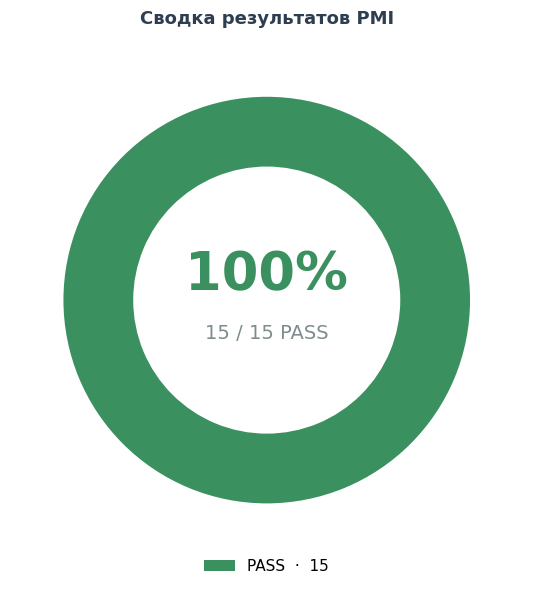

In [3]:
# Сводка и кольцевая диаграмма по статусам
status_counts = df["status"].value_counts()
total  = len(df)
passed = int(status_counts.get("PASS", 0))
failed = int(status_counts.get("FAIL", 0))
warned = int(status_counts.get("WARN", 0))

print(f"Всего проверок : {total}")
print(f"  PASS : {passed}")
print(f"  WARN : {warned}")
print(f"  FAIL : {failed}")

palette = {"PASS": "#3a915f", "WARN": "#d99a2b", "FAIL": "#c0392b"}
order   = ["PASS", "WARN", "FAIL"]
present = [s for s in order if s in status_counts.index]
sizes   = [int(status_counts[s]) for s in present]
cols    = [palette[s] for s in present]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, _ = ax.pie(
    sizes, colors=cols, startangle=90, counterclock=False,
    wedgeprops=dict(width=0.36, edgecolor="white", linewidth=3),
)
pct_pass = passed / total * 100
ax.text(0,  0.12, f"{pct_pass:.0f}%", ha="center", va="center",
        fontsize=38, weight="bold", color="#3a915f")
ax.text(0, -0.16, f"{passed} / {total} PASS", ha="center", va="center",
        fontsize=14, color="#7f8c8d")
ax.set_title("Сводка результатов PMI")

handles = [Patch(facecolor=palette[s], label=f"{s}  ·  {int(status_counts[s])}")
           for s in present]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.06),
          ncol=len(present), frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

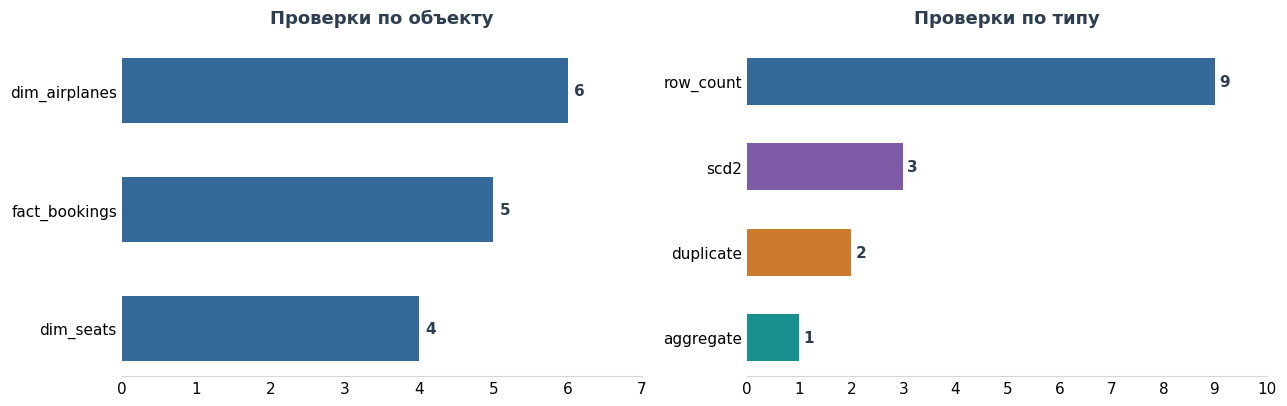

In [4]:
# Покрытие: проверки по объекту и по типу
def style_barh(ax, maxv):
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#cfd6dc")
    ax.tick_params(length=0)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_xlim(0, maxv + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

obj = df.groupby("object_name").size().sort_values()
axes[0].barh(obj.index, obj.values, color="#34699a", height=0.55)
axes[0].set_title("Проверки по объекту")
for i, v in enumerate(obj.values):
    axes[0].text(v + 0.08, i, str(v), va="center", weight="bold", color="#2c3e50")
style_barh(axes[0], obj.values.max())

typ  = df.groupby("check_type").size().sort_values()
tcol = {"row_count": "#34699a", "scd2": "#7d5ba6",
        "duplicate": "#cc7a2b", "aggregate": "#178f8f"}
axes[1].barh(typ.index, typ.values,
             color=[tcol.get(t, "#95a5a6") for t in typ.index], height=0.55)
axes[1].set_title("Проверки по типу")
for i, v in enumerate(typ.values):
    axes[1].text(v + 0.08, i, str(v), va="center", weight="bold", color="#2c3e50")
style_barh(axes[1], typ.values.max())

plt.tight_layout()
plt.show()

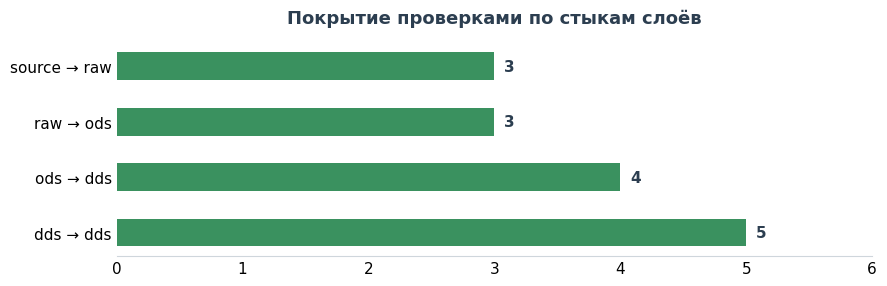

In [5]:
# Покрытие проверками по стыкам слоёв (от источника до DDS)
order_styk    = ["source → raw", "raw → ods", "ods → dds", "dds → dds"]
styk_counts   = df["styk"].value_counts()
present_styk  = [s for s in order_styk if s in styk_counts.index]
vals          = [int(styk_counts[s]) for s in present_styk]

fig, ax = plt.subplots(figsize=(9, 3.0))
ypos = list(range(len(present_styk)))
ax.barh(ypos, vals, color="#3a915f", height=0.5)
ax.set_yticks(ypos)
ax.set_yticklabels(present_styk)
ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v + 0.08, i, str(v), va="center", weight="bold", color="#2c3e50")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#cfd6dc")
ax.tick_params(length=0)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xlim(0, max(vals) + 1)
ax.set_title("Покрытие проверками по стыкам слоёв")
plt.tight_layout()
plt.show()

In [6]:
# Детальная таблица с подсветкой статусов
def highlight_status(val):
    bg = {"PASS": "#e3f1ea", "FAIL": "#f7e0dc", "WARN": "#f7edd9"}
    fg = {"PASS": "#2f7a4d", "FAIL": "#a5342a", "WARN": "#9a6c1f"}
    return f"background-color: {bg.get(val,'')}; color: {fg.get(val,'')}; font-weight: 700;"

show = df[["check_id", "object_name", "styk", "check_type",
           "src_value", "dwh_value", "diff", "status"]].copy()
show.columns = ["Код", "Объект", "Стык", "Тип",
                "Источник", "DWH", "Разница", "Статус"]

(show.style
    .map(highlight_status, subset=["Статус"])
    .format({"Источник": "{:,.0f}", "DWH": "{:,.0f}", "Разница": "{:,.2f}"})
    .set_caption("Детальные результаты PMI (последний прогон)")
    .hide(axis="index")
    .set_table_styles([
        {"selector": "caption",
         "props": "caption-side: top; font-size: 1.05em; font-weight: 700; "
                  "color: #2c3e50; padding: 8px 0;"},
        {"selector": "th",
         "props": "background-color: #34699a; color: white; font-weight: 600; "
                  "text-align: left; padding: 6px 12px;"},
        {"selector": "td",
         "props": "padding: 5px 12px; border-bottom: 1px solid #eef2f5;"},
    ]))

Код,Объект,Стык,Тип,Источник,DWH,Разница,Статус
AGG-01,fact_bookings,ods → dds,aggregate,"170,115,567,675","170,115,567,675",0.00,PASS
DUP-01,dim_seats,dds → dds,duplicate,0,0,0.00,PASS
DUP-02,fact_bookings,dds → dds,duplicate,0,0,0.00,PASS
RC-01,dim_airplanes,source → raw,row_count,10,10,0.00,PASS
RC-02,dim_airplanes,raw → ods,row_count,10,10,0.00,PASS
RC-03,dim_airplanes,ods → dds,row_count,10,10,0.00,PASS
RC-04,dim_seats,source → raw,row_count,"1,741","1,741",0.00,PASS
RC-05,dim_seats,raw → ods,row_count,"1,741","1,741",0.00,PASS
RC-06,dim_seats,ods → dds,row_count,"1,741","1,741",0.00,PASS
RC-07,fact_bookings,source → raw,row_count,"9,706,657","9,706,657",0.00,PASS


---

# 🔑 Изменения в генерации суррогатных ключей

Ключевая часть апгрейда — переход от `identity`-счётчиков к **детерминированным хеш-ключам** (`uuid`). Это убирает зависимость от автоинкремента и делает ключ воспроизводимым из бизнес-данных.

| Тип объекта | Формула ключа | Почему так |
|---|---|---|
| **DIM · SCD1** | `md5(natural_key)::uuid` | состояние одно — ключ зависит только от бизнес-ключа |
| **DIM · SCD2** | `md5(natural_key ‖ valid_from)::uuid` | у ключа несколько версий — `valid_from` различает их |
| **FACT** | `md5(natural_key ‖ source_system)::uuid` | зерно факта + идентификатор источника |